<>:171: SyntaxWarning: invalid escape sequence '\l'
<>:173: SyntaxWarning: invalid escape sequence '\l'
<>:171: SyntaxWarning: invalid escape sequence '\l'
<>:173: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1786/2883844048.py:171: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title(f'Quenching Disaster ($1/\ln^{POWER} n$): Broken Symmetry', fontsize=17, pad=15)
/tmp/ipykernel_1786/2883844048.py:173: SyntaxWarning: invalid escape sequence '\l'
  text_str = f"Quenching Dynamics:\nPower = {POWER}\nFilter: Im($\lambda$) > 0\n$\epsilon$ = {EPSILON}"


🚀 启动【暴力淬火】实验 | 冷却轨迹: 1/ln^3.0(n) | Δμ = -0.02 | 正向频率滤镜 ON

进度         | 结束 μ (冷寂点)      | R²       | 平均误差       | 耗时 (s)
---------------------------------------------------------------------------
[  1/100]  | 1.2000          | 0.9764   | 7.1746     | 5.51s
[ 20/100]  | 1.3535          | 0.9850   | 5.9624     | 7.83s
[ 40/100]  | 1.5152          | 0.9914   | 4.5416     | 61.88s
[ 60/100]  | 1.6768          | 0.9908   | 4.5850     | 150.72s
[ 80/100]  | 1.8384          | 0.9929   | 3.8594     | 168.22s
[100/100]  | 2.0000          | 0.9903   | 4.5293     | 183.98s
---------------------------------------------------------------------------
✅ 淬火扫描完成！总耗时: 165.55 分钟


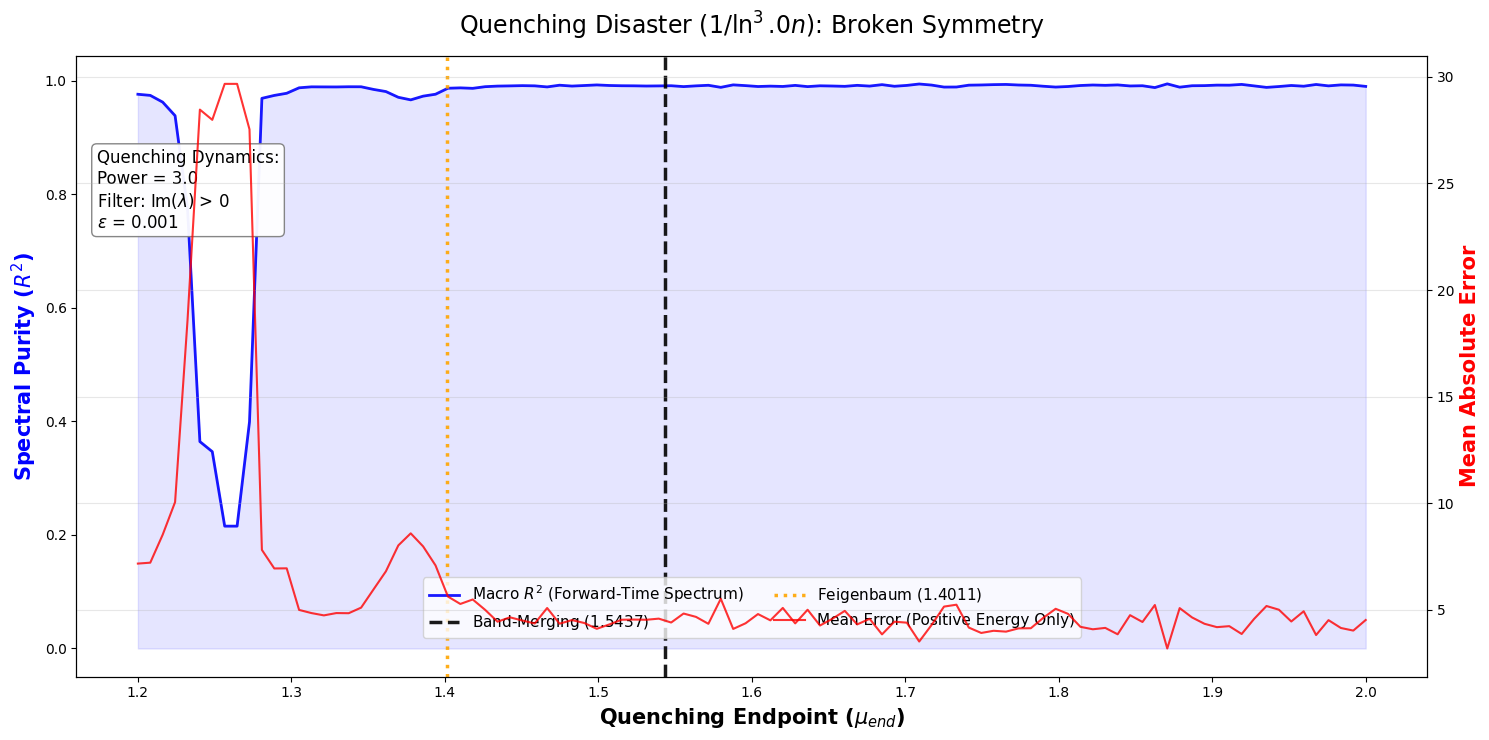

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# ================== 1. 真实的黎曼零点准备 ==================
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

# ================== 2. 高斯核概率溅射引擎 (带冷却速率 Power 参数) ==================
@njit
def run_universe_gaussian_splatting_power(steps, n_bins, u_c, k_opt, c_offset, eps, power):
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    V = np.zeros(n_bins, dtype=np.float64)
    
    dx = 2.0 / n_bins
    init_bin = int((0.5 + 1.0) / dx)
    if init_bin >= n_bins: init_bin = n_bins - 1
    elif init_bin < 0: init_bin = 0
    V[init_bin] = 1.0 
    
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1 
    
    for n in range(1, steps + 1):
        # 🎯 核心突变：冷却速度由 Power 决定！
        mu_raw = u_c + k_opt / (np.log(n + c_offset)**power)
        
        if mu_raw > 2.0: mu = 2.0
        elif mu_raw < 0.1: mu = 0.1
        else: mu = mu_raw
            
        V_next = np.zeros(n_bins, dtype=np.float64)
        
        for i in range(n_bins):
            if V[i] < 1e-12:
                continue
                
            x = -1.0 + dx * 0.5 + i * dx  
            x_next = 1.0 - mu * x * x     
            
            j_center = int((x_next + 1.0) / dx)
            j_start = max(0, j_center - radius)
            j_end = min(n_bins - 1, j_center + radius)
            
            w_sum = 0.0
            for j in range(j_start, j_end + 1):
                cj = -1.0 + dx * 0.5 + j * dx
                dist_sq = (cj - x_next) * (cj - x_next)
                w_sum += np.exp(-dist_sq * inv_2eps2)
            
            if w_sum > 1e-18:
                inv_w_sum = 1.0 / w_sum
                for j in range(j_start, j_end + 1):
                    cj = -1.0 + dx * 0.5 + j * dx
                    dist_sq = (cj - x_next) * (cj - x_next)
                    
                    prob = np.exp(-dist_sq * inv_2eps2) * inv_w_sum
                    flow = V[i] * prob
                    
                    V_next[j] += flow
                    transitions[i, j] += flow
            else:
                if j_center < 0: j_center = 0
                if j_center >= n_bins: j_center = n_bins - 1
                flow = V[i]
                V_next[j_center] += flow
                transitions[i, j_center] += flow
                
        V = V_next 
        
    return transitions

# ================== 3. 参数空间全景扫描 ==================
# test_points_end = np.linspace(1.20, 2.00, 500)
test_points_end = np.linspace(1.20, 2.00, 100) # 预览版跑100个点

TOTAL_STEPS = 10**5    
C_OFFSET = 10.0   
DELTA_MU_ABS = 0.02    
EPSILON = 0.001 

# 🎯 实验 3 的核心变量：冷却幂次
# Power = 3.0 (极速淬火) vs Power = 2.0 (标准退火)
POWER = 3.0 

results_R2 = []
results_mean_err = []

print(f"🚀 启动【暴力淬火】实验 | 冷却轨迹: 1/ln^{POWER}(n) | Δμ = -{DELTA_MU_ABS} | 正向频率滤镜 ON\n")
print(f"{'进度':<10} | {'结束 μ (冷寂点)':<15} | {'R²':<8} | {'平均误差':<10} | {'耗时 (s)'}")
print("-" * 75)

start_total_t = time.time()

for idx, mu_end in enumerate(test_points_end):
    start_point_t = time.time()
    
    # 🎯 逆向推导渐近线 U_C，匹配新的 Power
    t_start_val = 1.0 / (np.log(1 + C_OFFSET)**POWER)
    t_end_val   = 1.0 / (np.log(TOTAL_STEPS + C_OFFSET)**POWER)
    k_opt = DELTA_MU_ABS / (t_start_val - t_end_val)
    u_c = mu_end - k_opt * t_end_val
    
    trans = run_universe_gaussian_splatting_power(TOTAL_STEPS, 5000, u_c, k_opt, C_OFFSET, EPSILON, POWER)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        # 🔨 扩充求解数量 k，因为要丢弃一半的负能量
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS*2 + 20, which='LM', tol=1e-4)
        
        # 🎯【核心修复】物理过滤器：只提取上半平面（正向时间/正能量）
        # 剔除 imag < 0 的逆向时间流，防止 linregress 利用负斜率作弊
        positive_eigs = eigenvalues[eigenvalues.imag > 1e-4]
        
        phases = np.sort(np.angle(positive_eigs))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    if (idx + 1) % 20 == 0 or idx == 0:
        elapsed = time.time() - start_point_t
        print(f"[{idx+1:>3d}/{len(test_points_end)}]  | {mu_end:<15.4f} | {r2:<8.4f} | {err:<10.4f} | {elapsed:.2f}s")

print("-" * 75)
print(f"✅ 淬火扫描完成！总耗时: {(time.time()-start_total_t)/60:.2f} 分钟")

# ================== 4. 淬火相变灾难图 ==================
fig, ax1 = plt.subplots(figsize=(15, 7.5))

ax1_twin = ax1.twinx()

ax1.plot(test_points_end, results_R2, 'b-', lw=2, alpha=0.9, label='Macro $R^2$ (Forward-Time Spectrum)')
ax1.fill_between(test_points_end, results_R2, color='blue', alpha=0.1)
ax1_twin.plot(test_points_end, results_mean_err, 'r-', lw=1.5, alpha=0.8, label='Mean Error (Positive Energy Only)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2.5, alpha=0.9, label='Band-Merging ($1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2.5, alpha=0.9, label='Feigenbaum ($1.4011$)')

ax1.set_xlabel(r'Quenching Endpoint ($\mu_{end}$)', fontsize=15, fontweight='bold')
ax1.set_ylabel(r'Spectral Purity ($R^2$)', color='b', fontsize=15, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=15, fontweight='bold')
ax1.set_title(f'Quenching Disaster ($1/\ln^{POWER} n$): Broken Symmetry', fontsize=17, pad=15)

text_str = f"Quenching Dynamics:\nPower = {POWER}\nFilter: Im($\lambda$) > 0\n$\epsilon$ = {EPSILON}"
ax1.text(0.015, 0.85, text_str, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()